<a href="https://colab.research.google.com/github/odovgusha/Courses/blob/master/human_data_DeepSTARR_train_and_window_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overview

This tutorial will show you how to:
  1. Train DeepSTARR
  2. Compute nucleotide contribution scores
  3. Discover predictive motifs with TF-MoDISco

[DeepSTARR](https://www.nature.com/articles/s41588-022-01048-5) is a multi-task CNN built to quantitatively predict the activities of developmental and housekeeping enhancers from DNA sequence in *Drosophila melanogaster* S2 cells. Enhancer activities were assessed genome-wide using the transcriptional reporter assay [STARR-seq](https://www.science.org/doi/10.1126/science.1232542). You can find out more about it at https://github.com/bernardo-de-almeida/DeepSTARR.
Here we will use a subset of the enhancer activity data. To make things faster, we will only use 50,000 regions for training.

We start the tutorial from processed sequencing data (activity of different genomic sequences). This approach is suitable for different types of genomics data (e.g. ChIP-seq, ATAC-seq, DNase-seq) after the respective processing of the data.
We build DeepSTARR as a multi-task CNN but it could be easily adpated to single-task prediction tasks.

Use the 'Table of contents' on the left to navigate this notebook.

## Setup

Make sure you have enabled the GPU runtime by navigating to the menu 'Runtime', select 'Change runtime type' and set the runtime to 'GPU'.
Save a copy of this notebook in your Drive to run it and edit it.

[Google Colab - Quick Guide](https://www.tutorialspoint.com/google_colab/google_colab_quick_guide.htm)

### Install dependencies

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR')

Mounted at /content/drive


In [3]:
!python --version


Python 3.12.12


In [ ]:

#import condacolab
#condacolab.install()

In [4]:

#python DeepSTARR_pred_new_sequence.py -s ../../enhancers.hg38.test.filt.fa.out -m ../../Model_my_DeepSTARR_model_22062023

!pip install shap==0.41.0

!pip install deeplift

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 11.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for shap: filename=shap-0.41.0-cp312-cp312-linux_x86_64.whl size=521627 sha256=f437b0719f452aa7a7679bbd9375178fe374be4575415dc223bdcd3ca5bff9ed
  Stored in directory: /root/.cache/pip/wheels/e4/b0/46/ffff7adbedc5c6f3166da3706266c6282795ba48fb7d073c21
Successfully built shap
  Attempting uninstall: slicer
    Found existing installation: slicer 0.0.8
    Uninstalling slicer-0.0.8:
      Successfully uninstalled slicer-0.0.8
  Attempting uninstall: shap
    Found existing installation: shap 0.48.0
    Uninstalling shap-0.48.0:
      Successfully uninstalled shap-0.48.0
  Preparing metadata (setup.py) ... done
  Created wheel for deeplift: filename=deeplift-0.6.13.0-py3-none-any.whl size=36423 sha256=29f338adca4283d2b1f4d958ace498fd7049282aeed60b7a476dc338fe376

In [5]:

!pip install keras==2.12.0 tensorflow==2.12.0

ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1)
ERROR: No matching distribution found for tensorflow==2.12.0


In [6]:

!cd /content/drive/MyDrive/DeepSTARR_tutorial/

In [7]:
!ls /content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py


/content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py


In [ ]:

pip install tensorrt

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done


In [ ]:
#RUN IN DEEPSTARR/DEEPSTARR folder

In [ ]:

!ls /content/drive/MyDrive/DeepSTARR_tutorial/predictions_2

Lapos1_bima1_windows.fasta
Lapos1_bima1_windows.fasta_predictions_Model_my_DeepSTARR_model_19072023.txt
Lapos1_yoch6_windows.fasta
Lapos1_yoch6_windows.fasta_predictions_Model_my_DeepSTARR_model_19072023.txt
Lapos6_qolg1_windows.fasta
Lapos6_qolg1_windows.fasta_predictions_Model_my_DeepSTARR_model_19072023.txt
Lapos6_yoch6_windows.fasta
Lapos6_yoch6_windows.fasta_predictions_Model_my_DeepSTARR_model_19072023.txt
Lapos9_qolg1_windows.fasta
Lapos9_qolg1_windows.fasta_predictions_Model_my_DeepSTARR_model_19072023.txt
Lapos9_yoch6_windows.fasta
Lapos9_yoch6_windows.fasta_predictions_Model_my_DeepSTARR_model_19072023.txt


In [ ]:
filename = f"/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc_2/original_sequences.fasta"
!python  /content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py -s $filename -m /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023
filename = f"/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc_2/mutated_sequences.fasta"
!python  /content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py -s $filename -m /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023

Input FASTA file is  /content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc_2/original_sequences.fasta
Model file is  /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023
2023-12-05 01:36:12.035555: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-12-05 01:36:13.085648: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT

Loading sequences ...

(329, 2)
2023-12-05 01:36:15.582688: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/te

In [ ]:

filename = f"/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs2885718_var_2_A_windows.fasta"
!python  /content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py -s $filename -m /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023

Input FASTA file is  /content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs2885718_var_2_A_windows.fasta
Model file is  /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023
2023-11-08 12:40:38.623621: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Traceback (most recent call last):
  File "/content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py", line 46, in <module>
    from helper import IOHelper, SequenceHelper # from https://github.com/bernardo-de-almeida/Neural_Network_DNA_Demo.git
  File "<frozen importlib._bootstrap>", line 1027, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1006, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 688, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 879, in exec_module
  File "<frozen importlib._bootstrap_external>", line 975, in get_code
  File "<frozen i

In [ ]:
!ls /content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/*.fasta


/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs1060762_var_1_G_windows.fasta
/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs1060762_var_2_T_windows.fasta
/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs10848754_var_1_T_windows.fasta
/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs10848754_var_2_C_windows.fasta
/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs10896025_var_1_C_windows.fasta
/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs10896025_var_2_T_windows.fasta
/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs10917072_var_1_G_windows.fasta
/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs10917072_var_2_A_windows.fasta
/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs111317311_var_1_T_windows.fasta
/content/drive/MyDrive/DeepSTARR_tutor

In [ ]:

!ls $fasta_files_directory

blank_seq.fastq			       RELA_motifs_enrich_insert.fastq
CTCF_motifs_enrich_insert.fastq        RORB_motifs_enrich_insert.fastq
ETV5_FIGLA_motifs_enrich_insert.fastq  RXRA_VDR_motifs_enrich_insert.fastq
FOSL2_motifs_enrich_insert.fastq       SMAD2_motifs_enrich_insert.fastq
MAF_motifs_enrich_insert.fastq	       TEAD2_motifs_enrich_insert.fastq
NFATC4_motifs_enrich_insert.fastq      Thap11_motifs_enrich_insert.fastq
POU2F2_motifs_enrich_insert.fastq      ZNF341_motifs_enrich_insert.fastq


In [ ]:
import glob
import os
import subprocess
# Define the directory containing your fasta files
fasta_files_directory = '/content/drive/MyDrive/DeepSTARR_tutorial/motif_importance_2/'
# Use glob to create a list of fasta files
fasta_files = glob.glob(os.path.join(fasta_files_directory, '*.fastq'))

In [ ]:
!ls "/content/drive/MyDrive/DeepSTARR_tutorial/motif_importance_2/RXRA_VDR_motifs_enrich_insert.fastq"

/content/drive/MyDrive/DeepSTARR_tutorial/motif_importance_2/RXRA_VDR_motifs_enrich_insert.fastq


In [ ]:

#for i in range(1,(391+1)):
for i in fasta_files:
  #filename = f"/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs2885718_var_2_A_windows.fasta"
  !python  /content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py -s $i -m /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023
  !echo $i
  #!ls $filename

Input FASTA file is  /content/drive/MyDrive/DeepSTARR_tutorial/motif_importance_2/FOSL2_motifs_enrich_insert.fastq
Model file is  /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023
2023-11-28 00:58:21.771861: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-28 00:58:22.745696: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT

Loading sequences ...

(800, 2)
2023-11-28 00:58:25.414992: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/s

In [ ]:
import glob
import os
import subprocess
# Define the directory containing your fasta files
fasta_files_directory = '/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/'
# Use glob to create a list of fasta files
fasta_files = glob.glob(os.path.join(fasta_files_directory, '*.fasta'))

In [ ]:

#for i in range(1,(391+1)):
for i in fasta_files:
  #filename = f"/content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs2885718_var_2_A_windows.fasta"
  !python  /content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py -s $i -m /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023
  !echo $filename
  !ls $filename



Input FASTA file is  /content/drive/MyDrive/DeepSTARR_tutorial/ASOC_predictions/mutations_asoc/rs417234_var_1_G_windows.fasta
Model file is  /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023
2023-11-08 12:40:44.702524: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT

Loading sequences ...

(26, 2)
2023-11-08 12:40:49.343595: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
Traceback (most recent call last):
  File "/content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py", line 71, in <module>
    keras_model, keras_model_weights, keras_model_json = load_model(model_ID)
  File "/content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py", line 66, in load_model
    keras_model = model_from_json(open(keras_mod

In [ ]:
!python  /content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py -s /content/drive/MyDrive/DeepSTARR_tutorial/predictions_2/Lapos1_bima1_windows.fasta -m /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023
!python  /content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py -s /content/drive/MyDrive/DeepSTARR_tutorial/predictions_2/Lapos1_yoch6_windows.fasta -m /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023


In [ ]:

for i in range(2000,2001):
  filename = f"/content/drive/MyDrive/DeepSTARR_tutorial/enhancers.{i}bp.part1.hg38.filt.fa.out"
  !echo $filename
  !ls $filename

In [ ]:

#for i in range(1,(391+1)):
for i in range(1,(100+1)):
  filename = f"/content/drive/MyDrive/DeepSTARR_tutorial/fast_windows/1chr_part_{i}_DEEP_STAR_enhancers_input_200000bp_windows.bed_w499_s20.filt.fa.out"
  !python  /content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py -s $filename -m /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023
  !echo $filename
  !ls $filename

In [ ]:
!python  /content/drive/MyDrive/DeepSTARR_tutorial/DeepSTARR/DeepSTARR/DeepSTARR_pred_new_sequence.py -s /content/drive/MyDrive/DeepSTARR_tutorial/enhancers.2000bp.part1.hg38.filt.fa.out -m /content/drive/MyDrive/DeepSTARR_tutorial/Model_my_DeepSTARR_model_19072023


In [ ]:
!ls "/content/drive/MyDrive/DeepSTARR_tutorial/fast_windows"

In [ ]:

# change scikit version to be compatible
#!pip uninstall scikit-learn -y
#!pip install scikit-learn
#!pip install scikit-learn==1.0.1
# ignore ERROR: pip's dependency
import sklearn
print(sklearn.__version__)

1.2.2


In [ ]:
import tensorflow as tf
# import tensorflow.keras.layers as kl
# from tensorflow.keras.models import Sequential, Model
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, History, ModelCheckpoint

# using keras not from tensorflow.keras, to be compatible with shap module (for contribution scores)
import keras
import keras.layers as kl
from keras.models import Sequential, Model, load_model
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, History, ModelCheckpoint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import gdown

In [ ]:
# check module versions
print(tf.__version__)
print(keras.__version__)

2.12.0
2.12.0


[TensorFlow](https://www.tensorflow.org/) is an end-to-end open-source deep learning framework developed by Google and released in 2015. It is a symbolic math library used for neural networks and is best suited for dataflow programming across a range of tasks. It offers multiple abstraction levels for building and training models.

[Keras](https://keras.io/) is an effective high-level neural network Application Programming Interface (API) written in Python. This open-source neural network library is designed to provide fast experimentation with deep neural networks, and it can run on top of CNTK, TensorFlow, and Theano. Keras was adopted and integrated into TensorFlow in mid-2017. Users can access it via the tf.keras module. However, the Keras library can still operate separately and independently.

The main difference between Keras and tensorflow.keras is that tensorflow.keras is built on top of TensorFlow, while Keras can run on top of multiple backend engines. Since Tensorflow 2.0, tensorflow.keras is the default and I highly recommend to start working using tensorflow.keras.
Here, for compatibility reasons with the [shap](https://github.com/slundberg/shap) package to calculate nucleotide contribution scores, I will use the Keras API not from Tensorflow.


# Download STARR-seq data

<img src="https://github.com/bernardo-de-almeida/DeepSTARR/blob/main/img/gw_UMISTARRseq.png?raw=1" alt="STARR-seq data" width="800"/>

We used [STARR-seq](https://www.science.org/doi/10.1126/science.1232542) to generate genome-wide high-resolution quantitative activity maps of developmental and housekeeping enhancers, representing the two main transcriptional programs in *Drosophila* S2 cells. These genome-wide enhancer activity maps provide a high-quality dataset to build predictive models of enhancer activity and characterize the sequence determinants of two main enhancer types.

The input data used to train DeepSTARR is composed of 249-bp-long DNA sequences tiled across the genome and their respective developmental (Dev) and housekeeping (Hk) enhancer activities (log2 enrichment):
- The genome was binned into 249-bp windows with a stride of 100 bp, excluding chromosomes U, Uextra, and the mitochondrial genome
- We selected all windows at the summit of developmental and housekeeping enhancers, in addition to three windows on either side of the regions and a diversity of inactive sequences
- We augmented our dataset by adding the reverse complement of each original sequence, with the same output, ending up with 242,026 examples (484,052 postaugmentation)
- Sequences from the first (40,570; 8.4%) and second half of chr2R (41,186; 8.5%) were held out for validation and testing of the DeepSTARR model, respectively.

Here we will use a subset of the enhancer activity data. To make things faster, we will only use 50,000 regions for training, and keep the same 40,570 for validation and 41,186 for testing.

In [ ]:

from google.colab import drive
drive.mount('/content/drive')


In [ ]:
!ls /content/drive/MyDrive

 061960.full.pdf
 1009379771.pdf
'10.1016@j.gde.2017.01.003 (1).pdf'
 10.1016@j.gde.2017.01.003.pdf
 13059_2017_1345_MOESM1_ESM.pdf
 13059_2020_2156_MOESM1_ESM.pdf
'1-s2.0-S0092867413013007-main (1).pdf'
'2016-17_Engelke Wienands_Innate immunity summary (Recovered).gdoc'
'20221009-156380594-umsatz (1).CSV'
 20221009-156380594-umsatz.CSV
'29062022_gRNA desing.xlsx'
 2nd_TAC_K_Lysakovskaia.pdf
 3D_print
 41592_2018_BFnmeth4534_MOESM1_ESM.pdf
 acoustictrench_-_hurt_-_johnny_cash__nin_.pdf
 bts052.pdf
 calcSharpeningCurve.cpp
 calcSharpeningCurve.h
'Colab Notebooks'
'Constrained multi-body approaches for map.gslides'
'Data management STEFAN projects.gsheet'
 datasets.xlsx
 DeepSTARR_tutorial
 Diary.gdoc
 Dovgusha_Schwalb_lab_rot_1.pdf
'Draft Oleksandr.gdoc'
 EL#238_001.tif
 EL_G6-FLAG_quant_001.tif
 Enhancer_priming_analyses_candidates_07_04_2022.gsheet
 enhancers.2000bp.part1.hg38.filt.fa.out
 enhancers_2.hg38.filt.fa.out
'Estimation of (co-) transcriptional splicing with.pptx'
'Estimatio

In [ ]:
### Download genome-wide STARR-seq data
filename = '/content/drive/MyDrive/forward_and_rev_df_all_regions_600000.csv'
#filename = 'https://data.starklab.org/almeida/DeepSTARR/Tutorial/Sequences_activity_subset.txt' # subset of data (131,756 sequences), to be quicker, takes ~3min to load
# filename = 'https://data.starklab.org/almeida/DeepSTARR/Tutorial/Sequences_activity_all.txt' # if you want to try with the whole training data (484,052 sequences), takes ~3min to load

data = pd.read_table(filename)

In [ ]:
# check table with sequence info, DNA sequences (249bp), and log2 developmental and housekeeping enhancer activities
data

,seqnames,start,end,ID,Sequence,Dev_log2_enrichment,Hk_log2_enrichment,set
0,chr3,27985601,27986099,chr3_27985601_27986099_+_atac_peaks,CTAGTGCTGCCAAGATGAGGTACCACAGACTGGGTGGCTCAAACAA...,1.626242,1.626242,Train
1,chr6,7929201,7929699,chr6_7929201_7929699_+_negative,AGCTCTTATTATTTTGAGATGTGTCCCATCAATACCTAGTTTATTG...,-0.127212,-0.127212,Valid
2,chr3,68897701,68898199,chr3_68897701_68898199_+_negative,ACTGGTTCTGAATCACTGCTGGTCAAGACTGACCTTTGCTCAAGCT...,-0.560172,-0.560172,Train
3,chr8,81335401,81335899,chr8_81335401_81335899_+_atac_peaks,TATTGTGTTGGTGATTGCTATTTTATGTCCTCTTAGATGCCCTTTA...,0.323015,0.323015,Train
4,chr12,120496601,120497099,chr12_120496601_120497099_+_atac_peaks,CTCGACTGGAACCCTCCCACGGCTTAGGCTGCCAGCTTTCTTCCCT...,1.106091,1.106091,Train
...,...,...,...,...,...,...,...,...
187183,chr13,100088701,100089199,chr13_100088701_100089199_+_atac_peaks,TTCGGATTCTCGGGACTCCAGGGTGGCCAAGGCGCGGAGGTGACTC...,1.662221,1.662221,Train
187184,chr19,40632701,40633199,chr19_40632701_40633199_+_negative,GTGGCTGGGCAGATAGTAAGGTCTTGTTCTTTTCTCTTTTCCTTTC...,-0.453256,-0.453256,Train
187185,chr1,25616901,25617399,chr1_25616901_25617399_+_positive_peaks,CCCGCAGGCCCGCACCAAGCCGCCCTCCGCCCCCTAGGCTCCCGCC...,2.198820,2.198820,Train
187186,chr1,204004001,204004499,chr1_204004001_204004499_+_atac_peaks,GTGCTCTATCACCCCTTCAGCATGTTCATATGTGTTTTCTGACATG...,0.894394,0.894394,Train


In [ ]:
data['set'].replace({"Valid": "Val"}, inplace=True)

In [ ]:
# Enhancer sequences have the label 'positive_peaks' on the column 'ID' (n=24,559) - we will need that for the contribution scores later
data.loc[data['ID'].str.contains('_\+_positive_peaks')]

# the function above (str.contains) doesn't work in some pandas version - you can use the version below
# data.set_index('ID', drop=False).filter(regex='_\+_positive_peaks', axis=0)

,seqnames,start,end,ID,Sequence,Dev_log2_enrichment,Hk_log2_enrichment,set
11,chr1,13758901,13759399,chr1_13758901_13759399_+_positive_peaks,AACAAAAGGCTCAGAAACTGCATTGTTGCCCATTCTAAACGGCATT...,2.049882,2.049882,Train
12,chr1,16889101,16889599,chr1_16889101_16889599_+_positive_peaks,CTTCAAAGGACTAAAAGCTAAAGGCGACAATGAATTCATTCGACAA...,1.886512,1.886512,Train
15,chrX,115561101,115561599,chrX_115561101_115561599_+_positive_peaks,CACCCGAGCCAATGGCGGCGGCCGAGGGGCGGAGGGGGCTGGCAGG...,1.416369,1.416369,Train
22,chr2,100426401,100426899,chr2_100426401_100426899_+_positive_peaks,CTGACACTACCTGGAAAACTCATCTGTCCCTAAAGCCCACAATGCA...,1.652822,1.652822,Train
29,chr2,65056801,65057299,chr2_65056801_65057299_+_positive_peaks,CGGCTGGGCTTGGGAATGCCCGGGCGCGGCGAGGGAGTGCGCGAGT...,1.680837,1.680837,Train
...,...,...,...,...,...,...,...,...
187175,chr3,129316201,129316699,chr3_129316201_129316699_+_positive_peaks,CAGGCCTGGAGCCCCCCGGGCCGGGACAAGGCTCGGGTGCCCGTGG...,1.910458,1.910458,Train
187176,chr3,48301301,48301799,chr3_48301301_48301799_+_positive_peaks,GGCAAAGAAAATAACTGGGCAAGGTTTCCATCGGTGTCTCTGCTGG...,1.678899,1.678899,Train
187179,chr11,116343001,116343499,chr11_116343001_116343499_+_positive_peaks,TGAGAAGCACTGTATTTAATTAAGATATGTGTAAAACATGGTGAGA...,1.520748,1.520748,Train
187185,chr1,25616901,25617399,chr1_25616901_25617399_+_positive_peaks,CCCGCAGGCCCGCACCAAGCCGCCCTCCGCCCCCTAGGCTCCCGCC...,2.198820,2.198820,Train


In [ ]:
# check number of sequences between train/val/test data
counts = data['set'].value_counts()
print(counts)

Train    145774
Val       20764
Test      20649
Name: set, dtype: int64


## One-hot encode DNA sequence data

In [ ]:
# define a dictionary to map nucleotides to their one-hot encoded representation
nucleotide_dict = {'A': [1, 0, 0, 0],
                   'C': [0, 1, 0, 0],
                   'G': [0, 0, 1, 0],
                   'T': [0, 0, 0, 1],
                   'N': [0, 0, 0, 0]} # sometimes there are Ns

# define a function to one-hot encode a single DNA sequence
def one_hot_encode(seq):
    return np.array([nucleotide_dict[nuc] for nuc in seq])

# function to load sequences and enhancer activity
def prepare_input(data_set):

  # one-hot encode DNA sequences, apply function
  seq_matrix = np.array(data_set['Sequence'].apply(one_hot_encode).tolist())
  print(seq_matrix.shape) # dimensions are (number of sequences, length of sequences, nucleotides)

  # Get output array with dev and hk activities
  Y_dev = data_set.Dev_log2_enrichment
  Y_hk = data_set.Hk_log2_enrichment
  Y = [Y_dev, Y_hk]

  return seq_matrix, Y

In [ ]:
# Process data for train/val/test sets
X_train, Y_train = prepare_input(data[data['set'] == "Train"])
X_valid, Y_valid = prepare_input(data[data['set'] == "Val"])
X_test, Y_test = prepare_input(data[data['set'] == "Test"])

(145774, 499, 4)
(20764, 499, 4)
(20649, 499, 4)


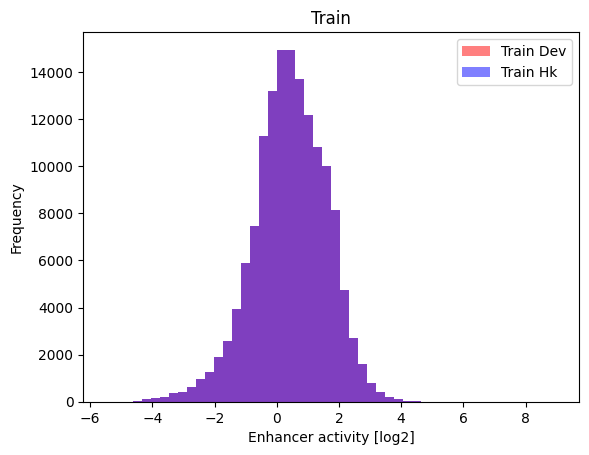

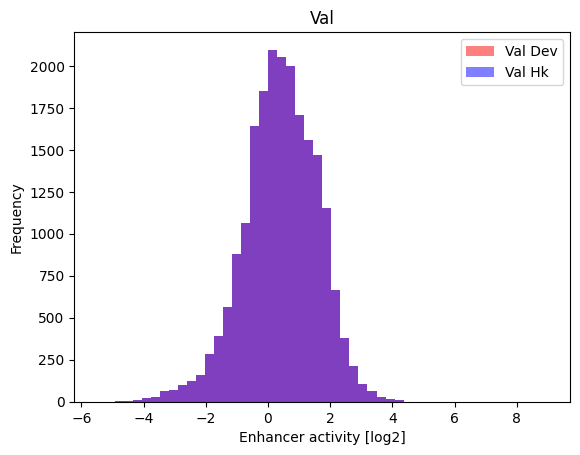

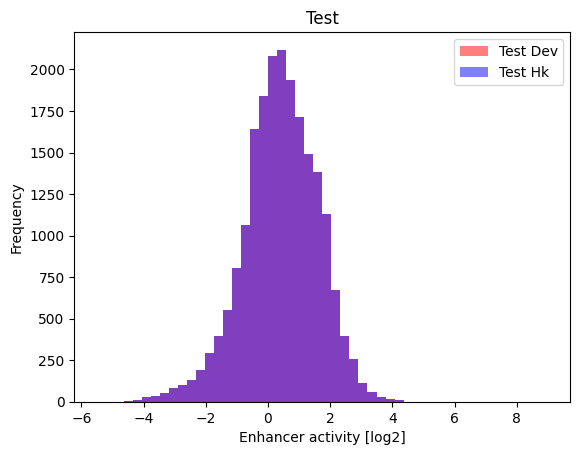

In [ ]:
# Look at distribution of output activities
def hist_activities(set, Y):

  plt.hist(Y[0], alpha=0.5, bins=50, label=set + ' Dev', color='red', range=[-5.5, 9])
  plt.hist(Y[1], alpha=0.5, bins=50, label=set +' Hk', color='blue', range=[-5.5, 9])

  plt.legend(loc='upper right')
  plt.xlabel('Enhancer activity [log2]')
  plt.ylabel('Frequency')
  plt.title(set)

  plt.show()

hist_activities("Train", Y_train)
hist_activities("Val", Y_valid)
hist_activities("Test", Y_test)

## Save data on your Google Drive
Let's save intermediate files in case you want to access it later withour running the cells above.

In [ ]:
# First mount drive - you need to permit this notebook to access your Google Drive files
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Check folder
!ls
!ls /content/drive/ # Your Drive should be here (MyDrive)

In [ ]:
# Create folder for the tutorial (inside /content/drive/MyDrive/)
!mkdir /content/drive/MyDrive/DeepSTARR_tutorial

In [ ]:
# This will save the data on Drive
import joblib

joblib.dump(data, '/content/drive/MyDrive/DeepSTARR_tutorial/data')

joblib.dump(X_train, '/content/drive/MyDrive/DeepSTARR_tutorial/X_train')
joblib.dump(Y_train, '/content/drive/MyDrive/DeepSTARR_tutorial/Y_train')

joblib.dump(X_valid, '/content/drive/MyDrive/DeepSTARR_tutorial/X_valid')
joblib.dump(Y_valid, '/content/drive/MyDrive/DeepSTARR_tutorial/Y_valid')

joblib.dump(X_test, '/content/drive/MyDrive/DeepSTARR_tutorial/X_test')
joblib.dump(Y_test, '/content/drive/MyDrive/DeepSTARR_tutorial/Y_test')

['/content/drive/MyDrive/DeepSTARR_tutorial/Y_test']

In [ ]:
# data can be loaded like this
# import joblib
# data = joblib.load('/content/drive/MyDrive/DeepSTARR_tutorial/data')

# X_train = joblib.load('/content/drive/MyDrive/DeepSTARR_tutorial/X_train')
# Y_train = joblib.load('/content/drive/MyDrive/DeepSTARR_tutorial/Y_train')

# X_valid = joblib.load('/content/drive/MyDrive/DeepSTARR_tutorial/X_valid')
# Y_valid = joblib.load('/content/drive/MyDrive/DeepSTARR_tutorial/Y_valid')

# X_test = joblib.load('/content/drive/MyDrive/DeepSTARR_tutorial/X_test')
# Y_test = joblib.load('/content/drive/MyDrive/DeepSTARR_tutorial/Y_test')


# Train DeepSTARR

Here we will build the DeepSTARR model architecture, train it on the input training data, and evaluate it on the test data.

## Build model architecture

<img src="https://github.com/bernardo-de-almeida/DeepSTARR/blob/main/img/DeepSTARR.png?raw=1" alt="DeepSTARR" width="700"/>

We build the multitask convolutional neural network DeepSTARR to map 249-bp-long DNA sequences tiled across the genome to both their developmental and their housekeeping enhancer activities (Fig. 1c).
We designed DeepSTARR with four convolution layers, each followed by a max-pooling layer, and two fully connected layers. The convolution layers identify local sequence features (for example, TF motifs) and increasingly complex patterns (for example, TF motif syntax), whereas the fully connected layers combine these features and patterns to predict enhancer activity separately for each enhancer type.

The loss function will be Mean Squared Error (MSE). MSE measures the average squared difference between the predicted values and the actual target values and is commonly used for regression problems. MSE is widely used because it penalizes large errors more heavily than small errors, and it has a well-defined mathematical formula that allows for efficient computation of the gradients during optimization.

In [ ]:
### Dictionary containing various hyperparameters for the model, to be more flexible to change them and test different model architectures

# These are the parameters from the main model trained using genome-wide data - more details at https://github.com/bernardo-de-almeida/DeepSTARR/tree/main/DeepSTARR
# params_full_gw_data = {'batch_size': 128,
#                       'epochs': 100,
#                       'early_stop': 5,
#                       'lr': 0.002,
#                       'n_conv_layer': 4,
#                       'num_filters1': 256,
#                       'num_filters2': 60,
#                       'num_filters3': 60,
#                       'num_filters4': 120,
#                       'kernel_size1': 7,
#                       'kernel_size2': 3,
#                       'kernel_size3': 5,
#                       'kernel_size4': 3,
#                       'n_dense_layer': 2,
#                       'dense_neurons1': 256,
#                       'dense_neurons2': 256,
#                       'dropout_conv': 'no',
#                       'dropout_prob': 0.4,
#                       'pad':'same'}


# Here we will adapt the model architecture for the training with the smaller data
# note the reduction in the number of layers, filters, neurons, addition of dropout on the convolutional layers
# this model has 165,354 parameters compared with 624,738 from the full model above
params_smaller_data = {'batch_size': 64, # number of examples per batch
                      'epochs': 100, # number of epochs
                      'early_stop': 10, # patience of 10 epochs to reduce training time; you can increase the patience to see if the model improves after more epochs
                      'lr': 0.001, # learning rate
                      'n_conv_layer': 3, # number of convolutional layers
                      'num_filters1': 128, # number of filters/kernels in the first conv layer
                      'num_filters2': 60, # number of filters/kernels in the second conv layer
                      'num_filters3': 60, # number of filters/kernels in the third conv layer
                      # 'num_filters4': 120,
                      'kernel_size1': 7, # size of the filters in the first conv layer
                      'kernel_size2': 3, # size of the filters in the second conv layer
                      'kernel_size3': 5, # size of the filters in the third conv layer
                      # 'kernel_size4': 3,
                      'n_dense_layer': 1, # number of dense/fully connected layers
                      'dense_neurons1': 64, # number of neurons in the dense layer
                      # 'dense_neurons2': 256,
                      'dropout_conv': 'yes', # add dropout after convolutional layers?
                      'dropout_prob': 0.4, # dropout probability
                      'pad':'same'}

def DeepSTARR(params):

    # expects sequences of length 249 with 4 channels, length of DNA sequences
    input = kl.Input(shape=(499, 4))

    # Body - 4 conv + batch normalization + ReLu activation + max pooling
    # The number of convolutional layers and their hyperparameters are determined by the values in the params dictionary.
    x = kl.Conv1D(params['num_filters1'], kernel_size=params['kernel_size1'],
                  padding=params['pad'],
                  name='Conv1D_1')(input)
    x = kl.BatchNormalization()(x)
    x = kl.Activation('relu')(x)
    x = kl.MaxPooling1D(2)(x)

    for i in range(1, params['n_conv_layer']):
        x = kl.Conv1D(params['num_filters'+str(i+1)],
                      kernel_size=params['kernel_size'+str(i+1)],
                      padding=params['pad'],
                      name=str('Conv1D_'+str(i+1)))(x)
        x = kl.BatchNormalization()(x)
        x = kl.Activation('relu')(x)
        x = kl.MaxPooling1D(2)(x)
        # add dropout after convolutional layers?
        if params['dropout_conv'] == 'yes': x = kl.Dropout(params['dropout_prob'])(x)

    # After the convolutional layers, the output is flattened and passed through a series of fully connected/dense layers
    # Flattening converts a multi-dimensional input (from the convolutions) into a one-dimensional array (to be connected with the fully connected layers
    x = kl.Flatten()(x)

    # Fully connected layers
    # Each fully connected layer is followed by batch normalization, ReLU activation, and dropout
    for i in range(0, params['n_dense_layer']):
        x = kl.Dense(params['dense_neurons'+str(i+1)],
                     name=str('Dense_'+str(i+1)))(x)
        x = kl.BatchNormalization()(x)
        x = kl.Activation('relu')(x)
        x = kl.Dropout(params['dropout_prob'])(x)

    # Main model bottleneck
    bottleneck = x

    # heads per task (developmental and housekeeping enhancer activities)
    # The final output layer is a pair of dense layers, one for each task (developmental and housekeeping enhancer activities), each with a single neuron and a linear activation function
    tasks = ['Dev', 'Hk']
    outputs = []
    for task in tasks:
        outputs.append(kl.Dense(1, activation='linear', name=str('Dense_' + task))(bottleneck))

    # Build Keras model object
    model = Model([input], outputs)
    model.compile(Adam(learning_rate=params['lr']), # Adam optimizer
                  loss=['mse', 'mse'], # loss is Mean Squared Error (MSE)
                  loss_weights=[1, 1]) # in case we want to change the weights of each output. For now keep them with same weights

    return model, params

# Having the paramters as a variable adds flexibility in case you want to test other architectures
DeepSTARR(params_smaller_data)[0].summary() # plot model architecture
DeepSTARR(params_smaller_data)[1] # show dictionary

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 499, 4)]     0           []                               
                                                                                                  
 Conv1D_1 (Conv1D)              (None, 499, 128)     3712        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 499, 128)    512         ['Conv1D_1[0][0]']               
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 499, 128)     0           ['batch_normalization[0][0]']

{'batch_size': 64,
 'epochs': 100,
 'early_stop': 10,
 'lr': 0.001,
 'n_conv_layer': 3,
 'num_filters1': 128,
 'num_filters2': 60,
 'num_filters3': 60,
 'kernel_size1': 7,
 'kernel_size2': 3,
 'kernel_size3': 5,
 'n_dense_layer': 1,
 'dense_neurons1': 64,
 'dropout_conv': 'yes',
 'dropout_prob': 0.4,
 'pad': 'same'}

## Train model

During model training, the model learns to make predictions on the provided data by updating its weights based on the loss between the predicted values and the actual values.
The goal of training is to minimize the difference between the predicted values and the actual values, which is achieved by finding the set of weights that produce the lowest loss on the training data.

In more detail, the training process involves the following steps:
- The model takes in the input data (training data) and produces a set of predicted values
- The predicted values are compared to the actual values using a loss function - in this case mean squared error (MSE)
- The optimizer updates the model's weights in order to minimize the loss (using backpropagation and gradient descent)
- The process is repeated for the specified number of epochs or until a stopping criterion is met (here no improvement in validation loss)
- Once training is complete, the trained model can be used to make predictions on new data (e.g. test set).

An epoch is a single iteration through the entire training dataset. During each epoch, the model updates its parameters based on the optimization algorithm, and then the validation loss is calculated using the validation set. Too few epochs may result in an underfit model that hasn't fully captured the underlying pattern in the training data, while too many epochs may lead to overfitting where the model performs well on the training data but poorly on the validation data.

<img src="https://storage.googleapis.com/kaggle-media/learn/images/eP0gppr.png" alt="loss" width="450"/>

During the training process, it is important to monitor the performance of the model on a validation set, which provides an estimate of the model's ability to generalize to new data (e.g. test set). The training process can be adjusted based on the performance on the validation set to prevent overfitting or underfitting. Here we used EarlyStopping to stop the training after some epochs of no improvement in the validation set.

The test set should never be used until we have the final model. The final model performance is then evaluated on the test set data.

In [ ]:
# function to to train model
def train(selected_model, X_train, Y_train, X_valid, Y_valid, params):

    my_history=selected_model.fit(X_train, Y_train,
                                  validation_data=(X_valid, Y_valid), # The function trains the selected_model using the training data and validates it using the validation data.
                                  batch_size=params['batch_size'],
                                  epochs=params['epochs'],
                                  callbacks=[EarlyStopping(patience=params['early_stop'], monitor="val_loss", restore_best_weights=True), # The training will stop early if there is no improvement in validation loss after a certain number of epochs (patience)
                                             History()])

    # save model and history
    return selected_model, my_history

In [ ]:
# Create model with specified parameters
# main_model, main_params = DeepSTARR(params_full_gw_data) # training the full model with the full training data takes almost all the GPU resources in Colab, but it's possible if you want to try
main_model, main_params = DeepSTARR(params_smaller_data) # adapted model architecture for smaller training set

# Run training, should take less than 10min, depending on when early stopping is activated
# Monitor model performance for each epoch

# We have two outputs (developmental and housekeeping), so there are two losses (Dense_Dev_loss, Dense_Hk_loss) and the final combined (loss; which is the sum) - for training and validation sets separately
# In each epoch, training occurs per batch of specified size.
# The batch size is the number of samples processed before the model's parameters are updated during a single iteration of the optimization algorithm. The number of epochs is the number of complete passes through the whole training dataset.
# Training's loss is calculated for the current batch and averaged successively during the epoch.
# Validation loss displays the loss of all the validation batches, at the end of each epoch.
main_model, my_history = train(main_model, X_train, Y_train, X_valid, Y_valid, main_params)

Epoch 1/100
2278/2278 [==============================] - 32s 12ms/step - loss: 2.1368 - Dense_Dev_loss: 1.0794 - Dense_Hk_loss: 1.0574 - val_loss: 1.8783 - val_Dense_Dev_loss: 0.9392 - val_Dense_Hk_loss: 0.9391
Epoch 2/100
2278/2278 [==============================] - 24s 11ms/step - loss: 1.8949 - Dense_Dev_loss: 0.9474 - Dense_Hk_loss: 0.9475 - val_loss: 1.8579 - val_Dense_Dev_loss: 0.9289 - val_Dense_Hk_loss: 0.9289
Epoch 3/100
2278/2278 [==============================] - 24s 10ms/step - loss: 1.8684 - Dense_Dev_loss: 0.9342 - Dense_Hk_loss: 0.9342 - val_loss: 2.1023 - val_Dense_Dev_loss: 1.0511 - val_Dense_Hk_loss: 1.0511
Epoch 4/100
2278/2278 [==============================] - 24s 10ms/step - loss: 1.8489 - Dense_Dev_loss: 0.9245 - Dense_Hk_loss: 0.9245 - val_loss: 1.8140 - val_Dense_Dev_loss: 0.9070 - val_Dense_Hk_loss: 0.9070
Epoch 5/100
2278/2278 [==============================] - 24s 11ms/step - loss: 1.8289 - Dense_Dev_loss: 0.9144 - Dense_Hk_loss: 0.9144 - val_loss: 1.8739 - 

## Evaluate the model

Evaluate the model through:
- looking at training and validation metrics in model training history
- assessing performance in held-out test set (e.g. Pearson and Spearman correlations)
- Plot the data and compare actual values with predicted ones for the test set

Note that the model training results will vary if you run it different times due to the random initialization of weights.

### Training history

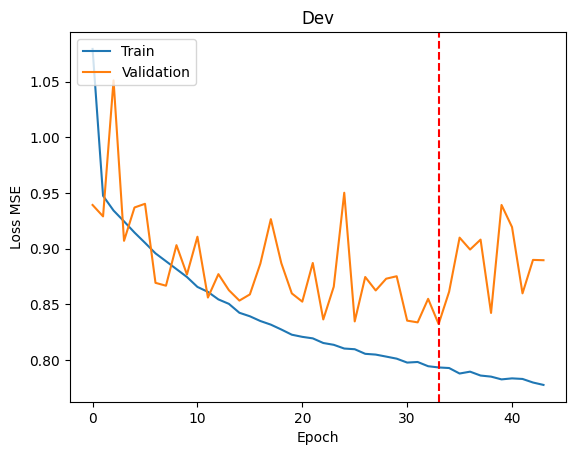

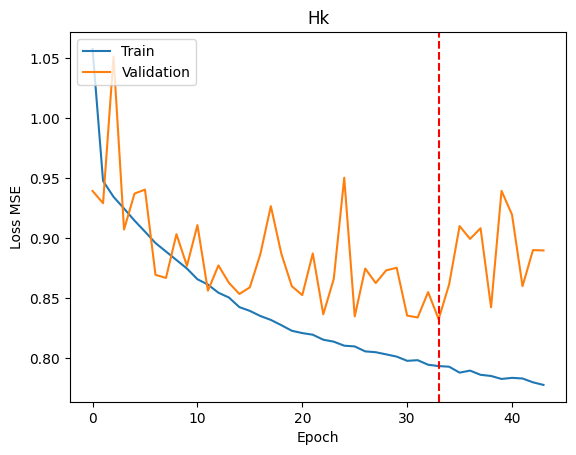

In [ ]:
# Plot training & validation training metrics
for out in ['Dev', 'Hk']:
  # MSE
  plt.plot(my_history.history[str('Dense_' + out + '_loss')])
  plt.plot(my_history.history[str('val_Dense_' + out + '_loss')])
  plt.title(out) # loss is Mean Squared Error (MSE)
  plt.ylabel('Loss MSE')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')

  # Add vertical line at minimum validation loss of combined dev and hk
  min_val_loss = min(my_history.history['val_loss'])
  plt.axvline(x=my_history.history['val_loss'].index(min_val_loss), color='red', linestyle='--')

  plt.show()

### Model performance metrics

Analyse Mean Squared Error (MSE) and Pearson (PCC) and Spearman (SCC) correlation coefficients

In [ ]:
from scipy import stats
from sklearn.metrics import mean_squared_error

# create functions
def summary_statistics(X, Y, set, task):
    pred = main_model.predict(X, batch_size=main_params['batch_size']) # predict
    if task =="Dev":
        i=0
    if task =="Hk":
        i=1
    print(set + ' MSE ' + task + ' = ' + str("{0:0.2f}".format(mean_squared_error(Y, pred[i].squeeze()))))
    print(set + ' PCC ' + task + ' = ' + str("{0:0.2f}".format(stats.pearsonr(Y, pred[i].squeeze())[0])))
    # print(set + ' SCC ' + task + ' = ' + str("{0:0.2f}".format(stats.spearmanr(Y, pred[i].squeeze())[0]))) # not giving similar results as training

# predict activity for each set and enhancer type
summary_statistics(X_train, Y_train[0], "train", "Dev")
summary_statistics(X_valid, Y_valid[0], "validation", "Dev")
summary_statistics(X_test, Y_test[0], "test", "Dev")

summary_statistics(X_train, Y_train[1], "train", "Hk")
summary_statistics(X_valid, Y_valid[1], "validation", "Hk")
summary_statistics(X_test, Y_test[1], "test", "Hk")

2278/2278 [==============================] - 7s 3ms/step
train MSE Dev = 0.73
train PCC Dev = 0.70
325/325 [==============================] - 1s 3ms/step
validation MSE Dev = 0.83
validation PCC Dev = 0.64
323/323 [==============================] - 1s 3ms/step
test MSE Dev = 0.86
test PCC Dev = 0.64
2278/2278 [==============================] - 7s 3ms/step
train MSE Hk = 0.73
train PCC Hk = 0.70
325/325 [==============================] - 1s 3ms/step
validation MSE Hk = 0.83
validation PCC Hk = 0.64
323/323 [==============================] - 1s 3ms/step
test MSE Hk = 0.86
test PCC Hk = 0.64


Although there is some overfitting (i.e. the performance is better in the training set than test set), the performance on the test data is still good. This suggests that the model accurately captures the regulatory information present in the DNA sequences, as you will see in the sections below.

### Scatter plots
The scatter plots compare the observed values with the predicted ones for each set of sequences (train/validation/testing). This allows to compare the global performance of the final model.

323/323 [==============================] - 1s 3ms/step


<ipython-input-35-0d77b8270bc1>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.plot(lims, lims, 'w', linestyle='dashed', transform=g.transData, color='grey')


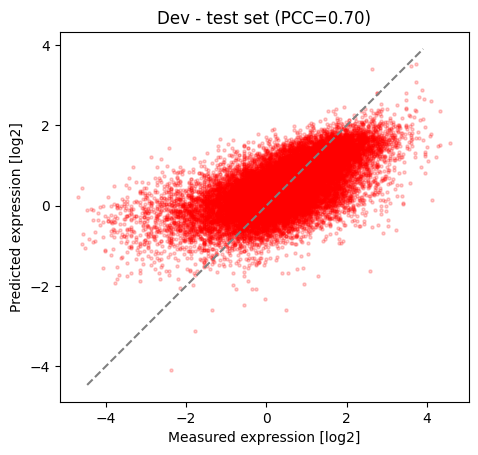

In [ ]:
def my_scatter(X, Y, set, task):
  pred = main_model.predict(X, batch_size=main_params['batch_size'])
  if task =="Dev":
    i=0
    c="red"
  if task =="Hk":
    i=1
    c="blue"

  g = sns.regplot(x=Y, y=pred[i].squeeze(), ci=None, color=c,
                  fit_reg=False,
                  scatter_kws={'s': 5, 'alpha': 0.2},
                  line_kws={'color': "black"})

  # add expected regression line
  x0, x1 = g.get_xlim()
  y0, y1 = g.get_ylim()
  lims = [max(x0, y0), min(x1, y1)]
  g.plot(lims, lims, 'w', linestyle='dashed', transform=g.transData, color='grey')

  # same axes ranges
  g.set_aspect('equal')
  # g.set(xlim=(min(x0, y0), max(x1, y1)),
  #       ylim=(min(x0, y0), max(x1, y1)))

  PCC = str("{0:0.2f}".format(stats.pearsonr(Y, pred[i].squeeze())[0]))
  plt.xlabel('Measured expression [log2]')
  plt.ylabel('Predicted expression [log2]')
  #plt.title(str(task + ' - ' + set + ' set (PCC=' + PCC + ')'))
  #plt.title(str(task + ' - ' + set + ' set (PCC=' + PCC + ')'))
  plt.title(str(task + ' - ' + set + ' set (PCC=' + "0.70" + ')'))

  #plt.show()
  plt.savefig("DEEPSTARR_corr_human_scatter.pdf", format="pdf", bbox_inches="tight")
  plt.show()

# plots


my_scatter(X_test, Y_test[0], "test", "Dev")
#my_scatter(X_test, Y_test[1], "test", "Hk")

323/323 [==============================] - 1s 3ms/step


<ipython-input-36-27f798a5b92e>:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


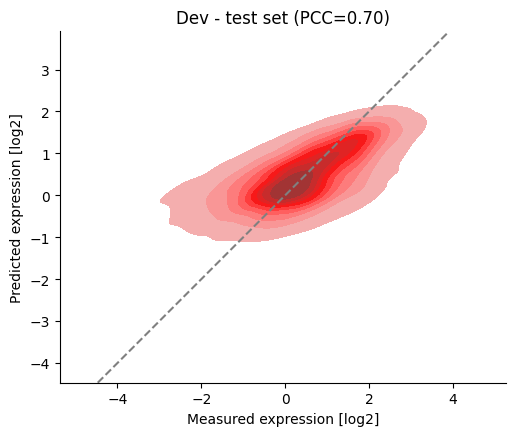

In [ ]:
### smoothscatter plot - useful when there are thousands of points

# takes some time to calculate the kernel density
def my_scatter_density(X, Y, set, task):
  pred = main_model.predict(X, batch_size=main_params['batch_size'])
  if task =="Dev":
    i=0
    c="red"
  if task =="Hk":
    i=1
    c="blue"

  g = sns.jointplot(x=Y, y=pred[i].squeeze(), kind="kde", fill=True, color=c)
  g.ax_marg_x.remove() # remove marginal densities
  g.ax_marg_y.remove() # remove marginal densities

  # add regression line of data
  # sns.regplot(x=Y, y=pred[i].squeeze(), scatter=False, color='black', ax=g.ax_joint)

  # add expected regression line
  x0, x1 = g.ax_joint.get_xlim()
  y0, y1 = g.ax_joint.get_ylim()
  lims = [max(x0, y0), min(x1, y1)]
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')

  # same axes ranges
  g.ax_joint.set_aspect('equal')

  PCC = str("{0:0.2f}".format(stats.pearsonr(Y, pred[i].squeeze())[0]))
  plt.xlabel('Measured expression [log2]')
  plt.ylabel('Predicted expression [log2]')
  #plt.title(str(task + ' - ' + set + ' set (PCC=' + PCC + ')'))
  plt.title(str(task + ' - ' + set + ' set (PCC=' + "0.70" + ')'))

  plt.savefig("DEEPSTARR_corr_human_dense.pdf", format="pdf", bbox_inches="tight")
  plt.show()

# print plots for test sets
my_scatter_density(X_test, Y_test[0], "test", "Dev")
#my_scatter_density(X_test, Y_test[1], "test", "Hk")

## Save model

In [ ]:
# This will save it on the current session's memory
main_model.save('my_DeepSTARR_model.h5')

### Save model on your Google Drive

In [ ]:
# Check folder
!ls
!ls /content/drive/ # Your Drive should be here (MyDrive)

drive			  Model_DeepSTARR_human.json  sample_data
Model_DeepSTARR_human.h5  my_DeepSTARR_model.h5
MyDrive


In [ ]:


model_name="my_DeepSTARR_model_19072023"
path='/content/drive/MyDrive/DeepSTARR_tutorial/'
model_json = main_model.to_json()
with open(path+'Model_' + model_name + '.json', "w") as json_file:
    json_file.write(model_json)
main_model.save_weights(path+'Model_' + model_name + '.h5')

In [ ]:
# This will save it on Google Drive
#main_model.save('/content/drive/MyDrive/DeepSTARR_tutorial/my_DeepSTARR_model_22062023.h5')

# Nucleotide contribution scores

<img src="https://bernardo-de-almeida.github.io/tutorials/DeepLearning_genomics/DeepSTARR_nucl_scores.png" alt="Nucl scores" width="700"/>

To understand the features and rules learned by DeepSTARR, we can quantify how each individual nucleotide in every sequence contributes to the predicted developmental and housekeeping enhancer activities.
We will use [DeepExplainer](https://github.com/slundberg/shap/#deep-learning-example-with-deepexplainer-tensorflowkeras-models) (the DeepSHAP implementation of [DeepLIFT](https://arxiv.org/abs/1704.02685); more details in the [GitHub repository](https://github.com/kundajelab/deeplift)). This method works by decomposing the output prediction of a neural network on a specific input by backpropagating the contributions of all neurons in the network to every feature of the input. Scores can be computed efficiently in a single backward pass.
More specifically, it explains the difference in the output relative to what the output is under some "reference" input. The ‘reference’ state is a distribution of background samples, chosen according to
what is appropriate for the problem at hand. Since it uses backpropagation, it can compute all scores at once, making it more efficient than in-silico mutagenesis (i.e. mutating every nucleotide and measuring its impact of the predicted value).

Above is an example of a developmental enhancer and its derived nucleotide contribution scores. Regions with high scores resembling known TF motifs are highlighted. These important/predictive motifs were learned *de novo* by the model.

## Install modules

In [ ]:
!pip install shap==0.41.0

!pip install deeplift

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 kB 40.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for deeplift: filename=deeplift-0.6.13.0-py3-none-any.whl size=36426 sha256=3996737db69855d751c17fece9d23923ba27618d1cc57bcb2995980f1f10eb6b
  Stored in directory: /root/.cache/pip/wheels/5d/d0/62/3f2d52f229601a9107ad95750d9b403c66063756100d374b6f
Successfully built deeplift


In [ ]:
# check module versions
print(tf.__version__)

import shap
print(shap.__version__)

# import deeplift
# print(deeplift.__version__)

2.12.0
0.41.0


## Load the model

Either load back the model trained above or the final model from the DeepSTARR paper trained on the whole training data

In [ ]:

# First mount drive - you need to permit this notebook to access your Google Drive files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls '/content/drive/MyDrive/DeepSTARR_tutorial/'

data					   notebook_env.db
DeepSTARR.model.h5			   X_cand_dev
DeepSTARR.model.json			   X_cand_hk
Dev_modisco_results.hdf5		   X_test
forward_and_rev_df_all_regions_600000.csv  X_train
Hk_modisco_results.hdf5			   X_valid
my_DeepSTARR_model_21062023.h5		   Y_test
my_DeepSTARR_model_22062023.h5		   Y_train
my_DeepSTARR_model_contr_scores.h5	   Y_valid
my_DeepSTARR_model.h5


In [ ]:
# Load the final model trained above
main_model = load_model('/content/drive/MyDrive/DeepSTARR_tutorial/my_DeepSTARR_model_22062023.h5')

#main_model.save('/content/drive/MyDrive/DeepSTARR_tutorial/my_DeepSTARR_model.h5')

In [ ]:
# Or load the final DeepSTARR model from the paper, trained on the whole training set (it's a retrained version, not the original one, but it's fine)
# It's more accurate than the one trained above on a subset of data
# It's available from the link below

# download model file
model_url = 'https://drive.google.com/uc?id=170d_WWlrM22xRzu0PbQmBjT2akvZ2ndn' # link to model trained on genome-wide data
output_path = 'DeepSTARR_model_gw_data.h5'
gdown.download(model_url, output_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=170d_WWlrM22xRzu0PbQmBjT2akvZ2ndn
To: /content/DeepSTARR_model_gw_data.h5
100%|██████████| 7.62M/7.62M [00:00<00:00, 21.4MB/s]


'DeepSTARR_model_gw_data.h5'

In [ ]:
# check files in folder - see the model file there
!ls -lh

total 12M
-rw-r--r-- 1 root root 7.3M Jul 12 10:10 DeepSTARR_model_gw_data.h5
drwx------ 5 root root 4.0K Jul 12 09:42 drive
-rw-r--r-- 1 root root 1.2M Jul 12 10:10 Model_DeepSTARR_human.h5
-rw-r--r-- 1 root root 8.7K Jul 12 10:10 Model_DeepSTARR_human.json
-rw-r--r-- 1 root root 3.4M Jul 12 10:10 my_DeepSTARR_model.h5
drwxr-xr-x 1 root root 4.0K Jul 10 13:38 sample_data


In [ ]:
# Load model
main_model = load_model(output_path)

In [ ]:
# check model architecture
main_model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 249, 4)]     0           []                               
                                                                                                  
 Conv1D_1 (Conv1D)              (None, 249, 256)     7424        ['input_3[0][0]']                
                                                                                                  
 batch_normalization_12 (BatchN  (None, 249, 256)    1024        ['Conv1D_1[0][0]']               
 ormalization)                                                                                    
                                                                                                  
 activation_12 (Activation)     (None, 249, 256)     0           ['batch_normalization_12[0]

## Calculate and visualise contribution scores

<img src="https://bernardo-de-almeida.github.io/tutorials/DeepLearning_genomics/DeepSTARR_nucl_scores_examples.png" alt="Nucl scores examples" width="1000"/>
DeepSTARR-derived Developmental and Housekeeping nucleotide contribution scores for a strong Developmental (left) and a strong Housekeeping (right) enhancer sequence, as example. Regions with high scores resembling known TF motifs are highlighted.

In [ ]:
### Check to which layer should we get the input nucleotide contributions
main_model.layers
# second to last layer is the Developmental activity final Dense layer: main_model.layers[-2]
# last layer is the Housekeeping activity final Dense layer: main_model.layers[-1]

# when using a sigmoid activation as final activation, compute the scores relative to the pre-sigmoid activation

### Prepare DeepExplainer

In [ ]:
import shap
# tf.compat.v1.disable_v2_behavior()
# tf.compat.v1.disable_eager_execution()

# import tensorflow.compat.v1.keras.backend as K
# import tensorflow as tf
# tf.compat.v1.disable_eager_execution()


# select a set of background examples to take an expectation over
np.random.seed(seed=1234)
background = X_test[np.random.choice(X_test.shape[0], 1000, replace=False)]

# Prepare DeepExplainer for developmental and housekeeping model output
shap.explainers._deep.deep_tf.op_handlers["AddV2"] = shap.explainers._deep.deep_tf.passthrough # this is required due to conflict between versions (https://github.com/slundberg/shap/issues/1110)
explainer_dev = shap.DeepExplainer((main_model.layers[0].input, main_model.layers[-2].output),
                                  data=background)
explainer_hk = shap.DeepExplainer((main_model.layers[0].input, main_model.layers[-1].output),
                                  data=background)

# ignore the warnings about keras

keras is no longer supported, please use tf.keras instead.
Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.


ValueError: ignored

### Developmental enhancers

We will run it on a selected set of enhancers from the test set to be faster, but this could be run across all enhancers.

In [ ]:
### Compute nucleotide contribution scores to developmental enhancers - takes ~3mins for this number of sequences

# get strong developmental enhancers from test set
# cand_dev = data.loc[(data['set'] == 'Test') &
#                     # (data['Oligo_ID'].str.contains('_\+_wt_dCP')) & # not working in some pandas version
#                     (data['Dev_log2_enrichment'] > 4)]
# cand_dev = cand_dev.set_index('Oligo_ID').filter(regex='_\+_wt_dCP', axis=0)

# Enhancer sequences have the label 'positive_peaks' on the column 'ID' - we will need that for the contribution scores later
cand_dev = data.loc[(data['set'] == 'Test') &
                    (data['ID'].str.contains('_\+_positive_peaks')) & # not working in some pandas version
                    (data['Dev_log2_enrichment'] > 3)]
# cand_dev = cand_dev.set_index('ID', drop=False).filter(regex='_\+_positive_peaks', axis=0) # if str.contains doesn't work

# sort by strength to have the stongest on top for later plotting
cand_dev = cand_dev.sort_values('Dev_log2_enrichment', ascending = False)
print(cand_dev)

# one-hot encode sequences
X_cand_dev, Y_cand_dev = prepare_input(cand_dev)

# Predict activity with model
pred_values_dev = main_model.predict(X_cand_dev)[0].squeeze() # 0 output for developmental

# calculate scores, get first element of output
shap_values_dev = explainer_dev.shap_values(X_cand_dev)[0]

In [ ]:
# Look at scores of one sequence, first 6 nucleotides - these are the hypothetical contribution scores
# rows are nucleotide positions, columns are A,C,G,T
shap_values_dev[0,:6]

These scores are for every nucleotide possibility in each position - called **Hypothetical scores**. They  can be thought of as quick estimates of what the contribution *would have been* if a different base were present.
Hypothetical scores are used as input to the importance score clustering algorithm TF-Modisco (https://github.com/kundajelab/tfmodisco).
Hypothetical importance scores are discussed more in this pull request: https://github.com/kundajelab/deeplift/pull/36.
<br></br>
To obtain the **actual contribution scores** for each sequence, below we multiply the hypothetical scores by the one-hot data - we use the contribution of whichever base was present.

In [ ]:
# multiply by one-hot sequence to keep only the scores of the actual nucleotides
final_contr_scores_dev = shap_values_dev*X_cand_dev
print(cand_dev.iloc[0]['Sequence'][:6]) # check DNA sequence
print(final_contr_scores_dev[0,:6]) # check scores - nucleotides should match DNA sequence

In [ ]:
### Plot scores of some top enhancers
from deeplift.visualization import viz_sequence # function from https://github.com/kundajelab/deeplift/blob/671ee67a03bd5bebf4c405af59eec45d3ca2a288/deeplift/visualization/viz_sequence.py

for i in range(5):
    print('Enhancer:', cand_dev.iloc[i]['ID'],
          ' / Obs act:', '{0:0.2f}'.format(cand_dev.iloc[i]['Dev_log2_enrichment']),
          ' / Pred act:', '{0:0.2f}'.format(pred_values_dev[i]))
    print('Actual contribution scores')
    viz_sequence.plot_weights(final_contr_scores_dev[i], figsize=(20,2), subticks_frequency=20)

    # print('Hypothetical contribution scores')
    # viz_sequence.plot_weights(shap_values_dev[i], figsize=(20,2), subticks_frequency=20)


See how TF motifs are nicely highlighted as predictive of enhancer activity by the model!
These were learned de novo in the convolutional filters  and match known developmental TF motifs.

### Housekeeping enhancers

We will run it on a selected set of enhancers from the test set to be faster, but this could be run across all enhancers.

In [ ]:
### Compute nucleotide contribution scores to developmental enhancers - takes ~3mins for this number of sequences

# get strong developmental enhancers from test set
# cand_hk = data.loc[(data['set'] == 'Test') &
#                     # (data['Oligo_ID'].str.contains('_\+_wt_dCP')) & # not working in some pandas version
#                     (data['Hk_log2_enrichment'] > 3)]
# cand_hk = cand_hk.set_index('Oligo_ID').filter(regex='_\+_wt_hkCP', axis=0)

# Enhancer sequences have the label 'positive_peaks' on the column 'ID' - we will need that for the contribution scores later
cand_hk = data.loc[(data['set'] == 'Test') &
                    (data['ID'].str.contains('_\+_positive_peaks')) & # not working in some pandas version
                    (data['Hk_log2_enrichment'] > 3)]
# cand_hk = cand_hk.set_index('ID', drop=False).filter(regex='_\+_positive_peaks', axis=0) # if str.contains doesn't work

# sort by strength to have the stongest on top for later plotting
cand_hk = cand_hk.sort_values('Hk_log2_enrichment', ascending = False)
print(cand_hk)

# one-hot encode sequences
X_cand_hk, Y_cand_hk = prepare_input(cand_hk)

# Predict activity with model
pred_values_hk = main_model.predict(X_cand_hk)[1].squeeze() # 0 output for housekeeping

# calculate scores, get first element of output
shap_values_hk = explainer_hk.shap_values(X_cand_hk)[0]

In [ ]:
# Look at scores of one sequence, first 6 nucleotides - these are the hypothetical contribution scores
# rows are nucleotide positions, columns are A,C,G,T
shap_values_hk[0,:6]

These scores are for every nucleotide possibility in each position - called **Hypothetical scores**. They  can be thought of as quick estimates of what the contribution *would have been* if a different base were present.
Hypothetical scores are used as input to the importance score clustering algorithm TF-Modisco (https://github.com/kundajelab/tfmodisco).
Hypothetical importance scores are discussed more in this pull request: https://github.com/kundajelab/deeplift/pull/36.
<br></br>
To obtain the **actual contribution scores** for each sequence, below we multiply the hypothetical scores by the one-hot data - we use the contribution of whichever base was present.

In [ ]:
# multiply by one-hot sequence to keep only the scores of the actual nucleotides
final_contr_scores_hk = shap_values_hk*X_cand_hk
print(cand_hk.iloc[0]['Sequence'][:6]) # check DNA sequence
print(final_contr_scores_hk[0,:6]) # check scores

In [ ]:
### Plot scores of some top enhancers
from deeplift.visualization import viz_sequence # function from https://github.com/kundajelab/deeplift/blob/671ee67a03bd5bebf4c405af59eec45d3ca2a288/deeplift/visualization/viz_sequence.py

for i in range(5):
    print('Enhancer:', cand_dev.iloc[i]['ID'],
          ' / Obs act:', '{0:0.2f}'.format(cand_hk.iloc[i]['Hk_log2_enrichment']),
          ' / Pred act:', '{0:0.2f}'.format(pred_values_hk[i]))
    print('Actual contribution scores')
    viz_sequence.plot_weights(final_contr_scores_hk[i], figsize=(20,2), subticks_frequency=20)

    # print('Hypothetical contribution scores')
    # viz_sequence.plot_weights(shap_values_hk[i], figsize=(20,2), subticks_frequency=20)

See how TF motifs are nicely highlighted as predictive of enhancer activity by the model!
These were learned de novo in the convolutional filters and match known housekeeping TF motifs.

## Save contribution scores for developmental and housekeeping enhancers

In [ ]:
import os
import h5py # https://www.christopherlovell.co.uk/blog/2016/04/27/h5py-intro.html

# out = 'my_DeepSTARR_model_contr_scores.h5'
# save on google Drive

#main_model = load_model('/content/drive/MyDrive/DeepSTARR_tutorial/my_DeepSTARR_model_21062023.h5')
out = '/content/drive/MyDrive/DeepSTARR_tutorial/my_DeepSTARR_model_21062023.h5'
f = h5py.File(out, 'w')

# save the actual contribution scores
g = f.create_group("contrib_scores")
g.create_dataset('Dev_contrib_scores', data=final_contr_scores_dev)
g.create_dataset('Hk_contrib_scores', data=final_contr_scores_hk)

# save the hypothetical contribution scores
g = f.create_group("hyp_contrib_scores")
g.create_dataset('Dev_contrib_scores', data=shap_values_dev)
g.create_dataset('Hk_contrib_scores', data=shap_values_hk)

f.close()

# and save data
joblib.dump(X_cand_dev, '/content/drive/MyDrive/DeepSTARR_tutorial/X_cand_dev')
joblib.dump(X_cand_hk, '/content/drive/MyDrive/DeepSTARR_tutorial/X_cand_hk')

In [ ]:
X_cand_dev

## Compare developmental and housekeeping scores for the same sequences

Above we calculated contribution scores for the developmental output only for developmental enhancers, and for the housekeeping output only for housekeeping enhancers.
Here we will choose a set of developmental- and housekeeping-specific enhancers and get their scores for both outputs. In other words, for each DNA sequence we will get the nucleotide importance for both developmental and housekeeping activity.

In [ ]:
data

In [ ]:
cand_dev_spec = data.loc[(data['set'] == 'Test') &
                    (data['ID'].str.contains('_\+_positive_peaks'))]
cand_dev_spec = cand_dev_spec.sort_values('Dev_log2_enrichment', ascending = False)

In [ ]:

cand_dev_spec

In [ ]:
### Compute nucleotide contribution scores for both outputs to developmental- or housekeeping-specific enhancers

# get strong developmental enhancers from test set
cand_dev_spec = data.loc[(data['set'] == 'Test') &
                    (data['ID'].str.contains('_\+_positive_peaks')) &
                    (data['Dev_log2_enrichment'] > 3)]
cand_dev_spec = cand_dev_spec.sort_values('Dev_log2_enrichment', ascending = False)

# get strong housekeeping enhancers from test set
cand_hk_spec = data.loc[(data['set'] == 'Test') &
                    (data['ID'].str.contains('_\+_positive_peaks')) &
                    (data['Hk_log2_enrichment'] > 3)]
cand_hk_spec = cand_hk_spec.sort_values('Dev_log2_enrichment', ascending = False)

# combine top 10 dev- and hk-specific enhancers
cand_specific_enh = pd.concat([cand_dev_spec.head(10),
                               cand_hk_spec.head(10)])
print(cand_specific_enh)

# one-hot encode sequences
X_cand_specific_enh, Y_cand_specific_enh = prepare_input(cand_specific_enh)

# Predict activity with model [but this is from the genome-wide model...]
pred_values_both = main_model.predict(X_cand_specific_enh)

# calculate scores, get first element of output, combine both dev and hk
shap_values_both = [explainer_dev.shap_values(X_cand_specific_enh)[0],
                   explainer_hk.shap_values(X_cand_specific_enh)[0]]

In [ ]:
# multiply by one-hot sequence to keep only the scores of the actual nucleotides
# in loop for dev and hk
final_contr_scores_both = [d*X_cand_specific_enh for d in shap_values_both]

print(cand_specific_enh.iloc[0]['Sequence'][:6]) # check DNA sequence
print('Dev scores')
print(final_contr_scores_both[0][0,:6]) # check dev scores
print('Hk scores')
print(final_contr_scores_both[1][0,:6]) # check hk scores

In [ ]:
### Plot scores of some top enhancers - compare dev and hk scores for the same sequence
from deeplift.visualization import viz_sequence # function from https://github.com/kundajelab/deeplift/blob/671ee67a03bd5bebf4c405af59eec45d3ca2a288/deeplift/visualization/viz_sequence.py

for i in [0,4,13,14]:
    enh_type = 'Dev' if cand_specific_enh.iloc[i]['Dev_log2_enrichment'] > cand_specific_enh.iloc[i]['Hk_log2_enrichment'] else 'Hk'
    print()
    print(enh_type, 'enhancer:', cand_specific_enh.iloc[i]['ID'])
    for t in [0,1]: # dev and hk
        enh_class = 'Dev' if t==0 else 'Hk'
        print(enh_class, 'scores')
        print('Enhancer:', cand_specific_enh.iloc[i]['ID'],
              ' / Obs', enh_class, 'act:', '{0:0.2f}'.format(cand_specific_enh.iloc[i][str(enh_class + '_log2_enrichment')]),
              ' / Pred', enh_class, 'act:', '{0:0.2f}'.format(pred_values_both[t].squeeze()[i]))
        viz_sequence.plot_weights(final_contr_scores_both[t][i], figsize=(20,2), subticks_frequency=20)

# Run TF-Modisco to discover motifs

We can use [TF-Modisco](https://github.com/kundajelab/tfmodisco) to systematically discover and summarize recurring highly scoring sequence patterns for each output into motifs, using the contribution scores computed above. For each output, TF–Modisco uses the contribution scores to identify, align and cluster seqlets across all sequences of interest into consolidated motifs. The TF-Modisco algorithm reconstructs less redundant and complete motif representations from the base-resolution contribution scores.
<img src="https://bernardo-de-almeida.github.io/tutorials/DeepLearning_genomics/Modisco_cartoon.png" alt="modisco dev" width="300"/>

Below are examples of DeepSTARR motifs, generated by TF-Modisco by summarizing recurring predictive sequence patterns from the sequences of all Developmental (left) and Housekeeping (right) enhancers.

<img src="https://bernardo-de-almeida.github.io/tutorials/DeepLearning_genomics/DeepSTARR_modisco_dev.png" alt="modisco dev" width="300"/>
<img src="https://bernardo-de-almeida.github.io/tutorials/DeepLearning_genomics/DeepSTARR_modisco_hk.jpg" alt="modisco hk" width="300"/>

TF-Modisco needs to be run on an homogeneous group of sequences with similar profiles, in this case either developmental or housekeeping enhancers.

<br></br>
Other possibility to derive motifs would be to look at individual convolutional filters (see examples [here](https://www.nature.com/articles/nbt.3300#Fig6) and [here](https://www.nature.com/articles/s41586-021-04262-z#Fig3)). Each filter in a convolutional layer is designed to detect a specific pattern or feature in the input. By visualizing the filter weights or activations, it is possible to gain insight into the types of patterns that the filter is sensitive to.

## Load model and contribution scores

In [ ]:
# Load the model
# main_model = load_model('my_DeepSTARR_model.h5') # model trained in this notebook
# main_model = load_model('/content/drive/MyDrive/DeepSTARR_tutorial/my_DeepSTARR_model.h5') # model trained in this notebook from google Drive

#main_model = load_model('DeepSTARR_model_gw_data.h5') # Final DeepSTARR model from paper, loaded also above

In [ ]:
# Load contribution scores
import h5py

# from google Drive
out = '/content/drive/MyDrive/DeepSTARR_tutorial/my_DeepSTARR_model_contr_scores.h5'
f = h5py.File(out,"r")
tasks = f["contrib_scores"].keys()
print(tasks)

In [ ]:
# You can also load a pre-made contribution scores object if needed
# contr_scores_url = 'https://drive.google.com/uc?id=1SCDbIrKbutpTLxaGFlblndFef34u8MQm' # link to contribution scores object
# contr_scores_path = 'my_DeepSTARR_model_contr_scores.h5'
# gdown.download(contr_scores_url, contr_scores_path, quiet=False)

# import h5py
# f = h5py.File(contr_scores_path,"r")
# tasks = f["contrib_scores"].keys()
# print(tasks)

In [ ]:
tasks


In [ ]:
# load contribution scores for the developmental and housekeeping enhancers (different tasks)
from collections import OrderedDict

task_to_scores = OrderedDict()
task_to_hyp_scores = OrderedDict()
for task in tasks:
    task_to_scores[task] = [np.array(x) for x in f['contrib_scores'][task]]
    task_to_hyp_scores[task] = [np.array(x) for x in f['hyp_contrib_scores'][task]]

f.close()

# load sequence data
import joblib
X_cand_dev = joblib.load('/content/drive/MyDrive/DeepSTARR_tutorial/X_cand_dev')
X_cand_hk = joblib.load('/content/drive/MyDrive/DeepSTARR_tutorial/X_cand_hk')

In [ ]:
# explore
print('Contribution scores for', len(task_to_scores['Dev_contrib_scores']), 'dev sequences')
print(task_to_scores['Dev_contrib_scores'][0][:6])

print('Hypothetical scores for', len(task_to_hyp_scores['Dev_contrib_scores']), 'dev sequences')
print(task_to_hyp_scores['Dev_contrib_scores'][0][:6])

print('Contribution scores for', len(task_to_scores['Hk_contrib_scores']), 'hk sequences')
print(task_to_scores['Hk_contrib_scores'][0][:6])

print('Hypothetical scores for', len(task_to_hyp_scores['Hk_contrib_scores']), 'hk sequences')
print(task_to_hyp_scores['Hk_contrib_scores'][0][:6])

## Run TF-Modisco

In [ ]:
# install TF-modisco
!pip install modisco

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
import modisco

# check parameters
import inspect
def get_default_args(func):
    signature = inspect.signature(func)
    return {
        k: v.default
        for k, v in signature.parameters.items()
        if v.default is not inspect.Parameter.empty
    }

get_default_args(modisco.tfmodisco_workflow.workflow.TfModiscoWorkflow)

### TF-Modisco function

In [ ]:
from importlib import reload
# reload(modisco.util)
# reload(modisco.pattern_filterer)
# reload(modisco.aggregator)
# reload(modisco.core)
# reload(modisco.seqlet_embedding.advanced_gapped_kmer)
# reload(modisco.affinitymat.transformers)
# reload(modisco.affinitymat.core)
# reload(modisco.affinitymat)
# reload(modisco.cluster.core)
# reload(modisco.cluster)
# reload(modisco.tfmodisco_workflow.seqlets_to_patterns)
# reload(modisco.tfmodisco_workflow)
# reload(modisco)

null_per_pos_scores = modisco.coordproducers.LaplaceNullDist(num_to_samp=5000)

# prepare TF-modisco function to run for dev or hk
def my_tfmodisco(task):

    # which sequences to use
    if task == 'Dev_contrib_scores': one_hot = X_cand_dev
    if task == 'Hk_contrib_scores': one_hot = X_cand_hk

    tfmodisco_results = modisco.tfmodisco_workflow.workflow.TfModiscoWorkflow(
                        #target_seqlet_fdr controls the stringency of the threshold used.
                        # the default value is 0.2
                        target_seqlet_fdr=0.2,
                        #min_passing_windows_frac and max_passing_windows_frac can be used
                        # to manually adjust the percentile cutoffs for importance
                        # scores if you feel that the cutoff
                        # defined by the null distribution is too stringent or too
                        # lenient. The default values are 0.03 and 0.2 respectively.
                        #min_passing_windows_frac=0.03,
                        #max_passing_windows_frac=0.2
                        #The sliding window size and flanks should be adjusted according to the expected length of the core motif and its flanks.
                        #If the window size or flank sizes are too long, you risk picking up more noise.
                        sliding_window_size=15,
                        flank_size=5,
                        max_seqlets_per_metacluster=50000,
                        seqlets_to_patterns_factory=
                            modisco.tfmodisco_workflow
                                    .seqlets_to_patterns
                                    .TfModiscoSeqletsToPatternsFactory(
                                #kmer_len, num_gaps and num_mismatches are used to
                                # derive kmer embeddings for coarse-grained affinity
                                # matrix calculation. kmer_len=6, num_gaps=1
                                # and num_mismatches=0 means
                                # that kmer embeddings using 6-mers with 1 gap will be
                                # used. The default is to use longer kmers, but this
                                # can take a while to run and can lead to
                                # out-of-memory errors on some systems.
                                # Empirically, 6-mers with 1-gap
                                # seem to give good results.
                                #During the seqlet clustering, motifs are trimmed to the central trim_to_window_size bp with the highest importance
                                trim_to_window_size=15,
                                #After the trimming is done, the seqlet is expanded on either side by initial_flank_to_add
                                initial_flank_to_add=5,
                                final_min_cluster_size=30
                        )
                   )(
                task_names=[task],
                contrib_scores=task_to_scores,
                hypothetical_contribs=task_to_hyp_scores,
                one_hot=one_hot,
                null_per_pos_scores = null_per_pos_scores)

    return tfmodisco_results


### Function to visualize TF-modisco motifs

In [ ]:
# function to visualize motifs
from collections import Counter
import numpy as np

from modisco.visualization import viz_sequence
reload(viz_sequence)
from matplotlib import pyplot as plt

import modisco.affinitymat.core
reload(modisco.affinitymat.core)
import modisco.cluster.phenograph.core
reload(modisco.cluster.phenograph.core)
import modisco.cluster.phenograph.cluster
reload(modisco.cluster.phenograph.cluster)
import modisco.cluster.core
reload(modisco.cluster.core)
import modisco.aggregator
reload(modisco.aggregator)

def modisco_motif_plots(task):

    # Load results
    if task == 'Dev_contrib_scores': hdf5_results = h5py.File("/content/drive/MyDrive/DeepSTARR_tutorial/Dev_modisco_results.hdf5","r") # from Google Drive
    if task == 'Hk_contrib_scores': hdf5_results = h5py.File("/content/drive/MyDrive/DeepSTARR_tutorial/Hk_modisco_results.hdf5","r") # from Google Drive

    metacluster_names = [
        x.decode("utf-8") for x in
        list(hdf5_results["metaclustering_results"]["all_metacluster_names"][:])]

    all_patterns = []


    if task == 'Dev_contrib_scores': background = np.mean(X_cand_dev, axis=(0,1))
    if task == 'Hk_contrib_scores': background = np.mean(X_cand_hk, axis=(0,1))

    # sequence background
    if task == 'Dev_contrib_scores': background = np.mean(X_cand_dev, axis=(0,1))
    if task == 'Hk_contrib_scores': background = np.mean(X_cand_hk, axis=(0,1))

    for metacluster_name in metacluster_names:
        print(metacluster_name)
        metacluster_grp = (hdf5_results["metacluster_idx_to_submetacluster_results"]
                                       [metacluster_name])
        print("activity pattern:",metacluster_grp["activity_pattern"][:])
        all_pattern_names = [x.decode("utf-8") for x in
                             list(metacluster_grp["seqlets_to_patterns_result"]
                                                 ["patterns"]["all_pattern_names"][:])]
        if (len(all_pattern_names)==0):
            print("No motifs found for this activity pattern")
        for pattern_name in all_pattern_names:
            print(metacluster_name, pattern_name)
            all_patterns.append((metacluster_name, pattern_name))
            pattern = metacluster_grp["seqlets_to_patterns_result"]["patterns"][pattern_name]
            print("total seqlets:",len(pattern["seqlets_and_alnmts"]["seqlets"]))
            # print("Actual importance scores:")
            # viz_sequence.plot_weights(pattern[str(task + "_contrib_scores")]["fwd"])
            # print("Hypothetical scores:")
            # viz_sequence.plot_weights(pattern[str(task + "_hypothetical_contribs")]["fwd"])
            print("IC-scaled, fwd and rev:")
            viz_sequence.plot_weights(viz_sequence.ic_scale(np.array(pattern["sequence"]["fwd"]),
                                                            background=background))
            viz_sequence.plot_weights(viz_sequence.ic_scale(np.array(pattern["sequence"]["rev"]),
                                                            background=background))

            #Plot the subclustering too, if available
            if ("subclusters" in pattern):
                print("PLOTTING SUBCLUSTERS")
                subclusters = np.array(pattern["subclusters"])
                twod_embedding = np.array(pattern["twod_embedding"])
                plt.scatter(twod_embedding[:,0], twod_embedding[:,1], c=subclusters, cmap="tab20")
                plt.show()
                for subcluster_name in list(pattern["subcluster_to_subpattern"]["subcluster_names"]):
                    subpattern = pattern["subcluster_to_subpattern"][subcluster_name]
                    print(subcluster_name.decode("utf-8"), "size", len(subpattern["seqlets_and_alnmts"]["seqlets"]))
                    subcluster = int(subcluster_name.decode("utf-8").split("_")[1])
                    plt.scatter(twod_embedding[:,0], twod_embedding[:,1], c=(subclusters==subcluster))
                    plt.show()
                    # viz_sequence.plot_weights(subpattern[str(task + "_hypothetical_contribs")]["fwd"])
                    # viz_sequence.plot_weights(subpattern[str(task + "_contrib_scores")]["fwd"])
                    viz_sequence.plot_weights(viz_sequence.ic_scale(np.array(subpattern["sequence"]["fwd"]),
                                                            background=background))

    hdf5_results.close()

## Developmental enhancers

Below we visualize the main motifs discovered by TF-modisco (metaclusters). For each I am showing also the different motif variants in their sub-sclusters (computed from the t-SNE plot).

These motifs were created from a small subset of enhancers to be faster. Ideally we would run on all developmental or housekeeping enhancers.

In [ ]:
# Run TF-Modisco - takes around 10mins
dev_tfmodisco_results = my_tfmodisco('Dev_contrib_scores')

# save results
import modisco.util
reload(modisco.util)
grp = h5py.File("/content/drive/MyDrive/DeepSTARR_tutorial/Dev_modisco_results.hdf5", "w") # on Google Drive
dev_tfmodisco_results.save_hdf5(grp)
grp.close()

In [ ]:
# Visualize motifs
modisco_motif_plots('Dev_contrib_scores')

## Housekeeping enhancers

In [ ]:
# Run TF-Modisco - takes around 10mins
hk_tfmodisco_results = my_tfmodisco('Hk_contrib_scores')

# save results
import modisco.util
reload(modisco.util)
grp = h5py.File("/content/drive/MyDrive/DeepSTARR_tutorial/Hk_modisco_results.hdf5", "w") # on Google Drive
hk_tfmodisco_results.save_hdf5(grp)
grp.close()

In [ ]:
# Visualize motifs
modisco_motif_plots('Hk_contrib_scores')

# Additional exercises to practice
- Train the model using the whole training data (link for the data at the beguining: Sequences_activity_all.txt) and compare the model performance and nucleotide contribution scores
- Try to improve the model by adapting the model hyperparamters or use a different architecture (e.g. add dilated convolutions or residual connections)